# Exjobb Latency Analysis

In [72]:
%pip install numpy matplotlib pandas

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [73]:
def get_trace_dataset(expid, runid):
    df = pd.read_csv(f'./traces/{expid}/{runid}/{runid}-trace.csv')
    return df

def get_experiment_info(expid):
    info = {}
    with open(f'./traces/{expid}/info.txt', 'r') as f:
        for i, line in enumerate(f):
            if i == 7:
                info['Dataplane'] = line.split(':')[1].strip()
            elif i == 8:
                info['Protocol'] = line.split(':')[1].strip()
            elif i == 9:
                info['Policy Direction'] = line.split(':')[1].strip()
            elif i == 10:
                info['Istio Installed'] = line.split(':')[1].strip()
            elif i == 11:
                info['Istio Policy'] = line.split(':')[1].strip()
    
    return info



0.00036870980105105106
0.00036478620695695697
0.0003731427126379137
0.0003703194736973948


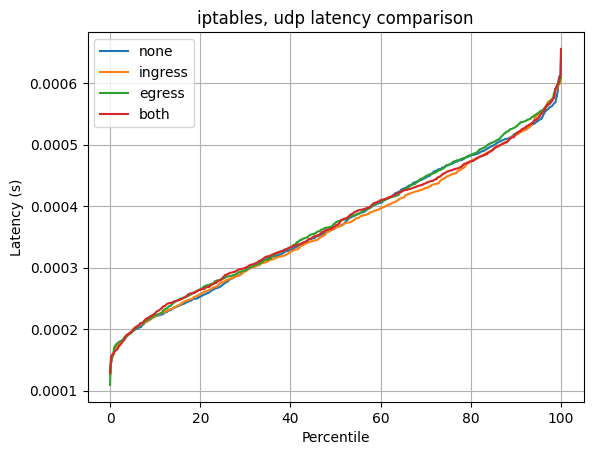

In [74]:
experimentstocompare = [{'id': '40634', 'run': '1'}, {'id': '40635', 'run': '1'}, {'id': '40636', 'run': '1'}, {'id': '40637', 'run': '1'}]
datasets = []
for exp in experimentstocompare:
    # print(get_experiment_info(exp['id']))
    df = get_trace_dataset(exp['id'], exp['run'])
    datasets.append(df)
    latencies = df['delay']
    
    # Remove outliers using IQR method
    Q1 = latencies.quantile(0.25)
    Q3 = latencies.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = max(Q1 - 1.5 * IQR, 0)  # Ensure non-negative
    upper_bound = Q3 + 1.5 * IQR
    latencies = latencies[(latencies >= lower_bound) & (latencies <= upper_bound)]
    
    print(latencies.mean())
    quantiles = latencies.quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.999])
    # print(quantiles)

    sorted_lat = np.sort(latencies)
    p = np.linspace(0, 100, len(sorted_lat))

    plt.plot(p, sorted_lat, label=get_experiment_info(exp['id'])['Policy Direction'])
    # plt.bar(get_experiment_info(exp['id'])['Policy Direction'], df['delay'].mean(), label=exp['id'])

plt.xlabel("Percentile")
plt.ylabel("Latency (s)")
plt.title(f"{get_experiment_info(exp['id'])['Dataplane']}, {get_experiment_info(exp['id'])['Protocol']} latency comparison")
plt.grid(True)
plt.legend()
plt.show()

#plt.boxplot([df['delay'] for df in datasets], tick_labels=experimentstocompare)
#plt.show()

0.00044475340475000005
0.00044101387275
0.0004472979256012024
0.0004540578115


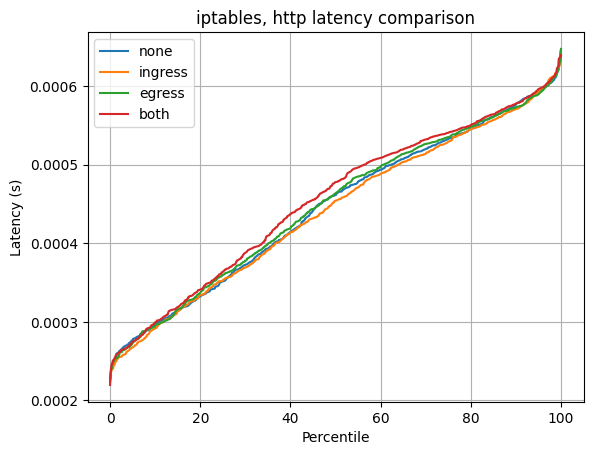

In [75]:
experimentstocompare = [{'id': '40638', 'run': '1'}, {'id': '40639', 'run': '1'}, {'id': '40640', 'run': '1'}, {'id': '40641', 'run': '1'}]
datasets = []

for exp in experimentstocompare:
    # print(get_experiment_info(exp['id']))
    df = get_trace_dataset(exp['id'], exp['run'])
    datasets.append(df)
    latencies = df['Delay (s)']
    
    # Remove outliers using IQR method
    Q1 = latencies.quantile(0.25)
    Q3 = latencies.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = max(Q1 - 1.5 * IQR, 0)  # Ensure non-negative
    upper_bound = Q3 + 1.5 * IQR
    latencies = latencies[(latencies >= lower_bound) & (latencies <= upper_bound)]
    
    print(latencies.mean())
    quantiles = latencies.quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.999])
    # print(quantiles)

    sorted_lat = np.sort(latencies)
    p = np.linspace(0, 100, len(sorted_lat))

    plt.plot(p, sorted_lat, label=get_experiment_info(exp['id'])['Policy Direction'])
    # plt.bar(get_experiment_info(exp['id'])['Policy Direction'], df['delay'].mean(), label=exp['id'])

plt.xlabel("Percentile")
plt.ylabel("Latency (s)")
plt.title(f"{get_experiment_info(exp['id'])['Dataplane']}, {get_experiment_info(exp['id'])['Protocol']} latency comparison")
plt.grid(True)
plt.legend()
plt.show()

#plt.boxplot([df['delay'] for df in datasets], tick_labels=experimentstocompare)
#plt.show()